# Decision Tree Classifier 

In [10]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [9]:
from sklearn.datasets import load_iris

In [12]:
iris =load_iris()

In [13]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [16]:
df=pd.DataFrame(iris['data'])

In [17]:
df

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [18]:
df.describe

<bound method NDFrame.describe of        0    1    2    3
0    5.1  3.5  1.4  0.2
1    4.9  3.0  1.4  0.2
2    4.7  3.2  1.3  0.2
3    4.6  3.1  1.5  0.2
4    5.0  3.6  1.4  0.2
..   ...  ...  ...  ...
145  6.7  3.0  5.2  2.3
146  6.3  2.5  5.0  1.9
147  6.5  3.0  5.2  2.0
148  6.2  3.4  5.4  2.3
149  5.9  3.0  5.1  1.8

[150 rows x 4 columns]>

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [22]:
print(df.columns)

RangeIndex(start=0, stop=4, step=1)


In [26]:
#so main problem im having that there is no column defined as such idky so, i have to write it,
x=pd.DataFrame(iris['data'] , columns= ['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'])

In [27]:
y = iris['target']

In [34]:
#independent feature
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [32]:
#dependent feature
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [31]:
#yup it is done i have taken the feature name from above data descrp...
#les first divide it into two x , y and then  go n do DT
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test  = train_test_split(x,y , test_size=0.20 , random_state=22)

In [37]:
#DT
from sklearn.tree import DecisionTreeClassifier
treeclassifier = DecisionTreeClassifier()

In [42]:
treeclassifier.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [43]:
#visualizing the DT
from sklearn import tree

[Text(0.5416666666666666, 0.9166666666666666, 'x[2] <= 2.45\ngini = 0.664\nsamples = 120\nvalue = [44, 40, 36]'),
 Text(0.4583333333333333, 0.75, 'gini = 0.0\nsamples = 44\nvalue = [44, 0, 0]'),
 Text(0.5, 0.8333333333333333, 'True  '),
 Text(0.625, 0.75, 'x[3] <= 1.75\ngini = 0.499\nsamples = 76\nvalue = [0, 40, 36]'),
 Text(0.5833333333333333, 0.8333333333333333, '  False'),
 Text(0.4166666666666667, 0.5833333333333334, 'x[2] <= 5.05\ngini = 0.133\nsamples = 42\nvalue = [0, 39, 3]'),
 Text(0.25, 0.4166666666666667, 'x[0] <= 4.95\ngini = 0.05\nsamples = 39\nvalue = [0, 38, 1]'),
 Text(0.16666666666666666, 0.25, 'x[2] <= 3.9\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.08333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.25, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 37\nvalue = [0, 37, 0]'),
 Text(0.5833333333333334, 0.4166666666666667, 'x[3] <= 1.55\ngin

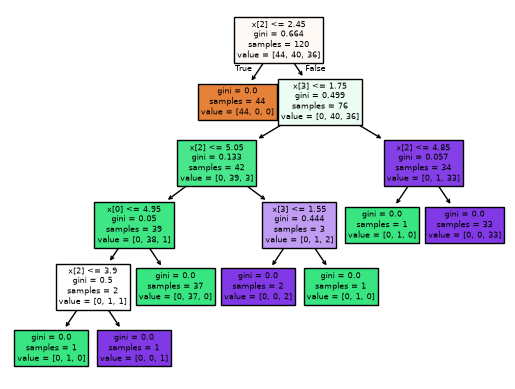

In [45]:
plt.Figure(figsize=(15,20))
tree.plot_tree(treeclassifier, filled=True)

whenever we use DT we might get some overfitting 

In [46]:
y_pred = treeclassifier.predict(x_test)

In [57]:
from sklearn.metrics import confusion_matrix, accuracy_score , classification_report

In [ ]:
print(accuracy_score(y_test, y_pred))
#print('\n')
print(confusion_matrix(y_test, y_pred))
#
# print('\n')
print(classification_report(y_test, y_pred))

0.8666666666666667
[[ 6  0  0]
 [ 0 10  0]
 [ 0  4 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.71      1.00      0.83        10
           2       1.00      0.71      0.83        14

    accuracy                           0.87        30
   macro avg       0.90      0.90      0.89        30
weighted avg       0.90      0.87      0.87        30



## PRE-PRUNNING
mainly hyparameter

In [63]:
param = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", None]
}

In [64]:
param

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5],
 'max_features': ['sqrt', 'log2', None]}

In [65]:
from sklearn.model_selection import GridSearchCV

In [66]:
treeclassifier2= DecisionTreeClassifier() 

In [ ]:
grid = GridSearchCV(treeclassifier , param_grid=param ,
                      cv=5 , scoring="scoring="accuracy" ) 

NameError: name 'clf' is not defined

In [69]:
grid.fit(x_train , y_train)

InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'balanced_accuracy', 'f1_weighted', 'neg_root_mean_squared_log_error', 'neg_median_absolute_error', 'neg_mean_squared_error', 'top_k_accuracy', 'jaccard_macro', 'd2_absolute_error_score', 'neg_mean_absolute_error', 'neg_max_error', 'jaccard_samples', 'r2', 'jaccard', 'adjusted_mutual_info_score', 'precision_weighted', 'neg_brier_score', 'recall', 'mutual_info_score', 'f1_samples', 'neg_mean_squared_log_error', 'f1_micro', 'neg_negative_likelihood_ratio', 'matthews_corrcoef', 'precision', 'neg_log_loss', 'recall_samples', 'v_measure_score', 'recall_micro', 'average_precision', 'precision_micro', 'accuracy', 'f1_macro', 'precision_macro', 'completeness_score', 'd2_brier_score', 'f1', 'roc_auc_ovo_weighted', 'homogeneity_score', 'recall_weighted', 'neg_mean_absolute_percentage_error', 'rand_score', 'fowlkes_mallows_score', 'neg_root_mean_squared_error', 'roc_auc', 'neg_mean_poisson_deviance', 'jaccard_weighted', 'roc_auc_ovr_weighted', 'd2_log_loss_score', 'recall_macro', 'explained_variance', 'neg_mean_gamma_deviance', 'roc_auc_ovr', 'jaccard_micro', 'adjusted_rand_score', 'precision_samples', 'roc_auc_ovo', 'normalized_mutual_info_score', 'positive_likelihood_ratio'}, a callable, an instance of 'list', an instance of 'tuple', an instance of 'dict' or None. Got 'accuracy_score' instead.